# Configuración básica (no tocar)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [24]:
x = Variable()

# Implementación de métodos

In [25]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    # f'(a) y f'(b) deben tener signos opuestos para garantizar que hay un cero entre ellos
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2  # punto medio del intervalo
        df_mid = df.eval(mid)
        # se alcanzó la precisión deseada: f' ≈ 0 o el intervalo es suficientemente pequeño
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step
        # se achica el intervalo según el signo de f' en el punto medio
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    # se alcanzó el máximo de iteraciones sin converger
    return (a + b) / 2, max_iter

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()   # calcula f'
    d2f = df.derivative()  # calcula f''
    xn  = x0
    for step in range(1, max_iter + 1):
        df_val  = df.eval(xn)
        d2f_val = d2f.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(df_val) < tol:
            return xn, step
        # si f'' ≈ 0 no se puede dividir, el método no puede continuar
        if abs(d2f_val) < 1e-12:
            raise ValueError(f"f''({xn}) ≈ 0: Newton no puede continuar.")
        xn = xn - df_val / d2f_val  # actualización: x = x - f'(x)/f''(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    xn = x0
    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(grad) < tol:
            return xn, step
        xn = xn - lr * grad  # actualización: x = x - lr * f'(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

### Prueba de métodos

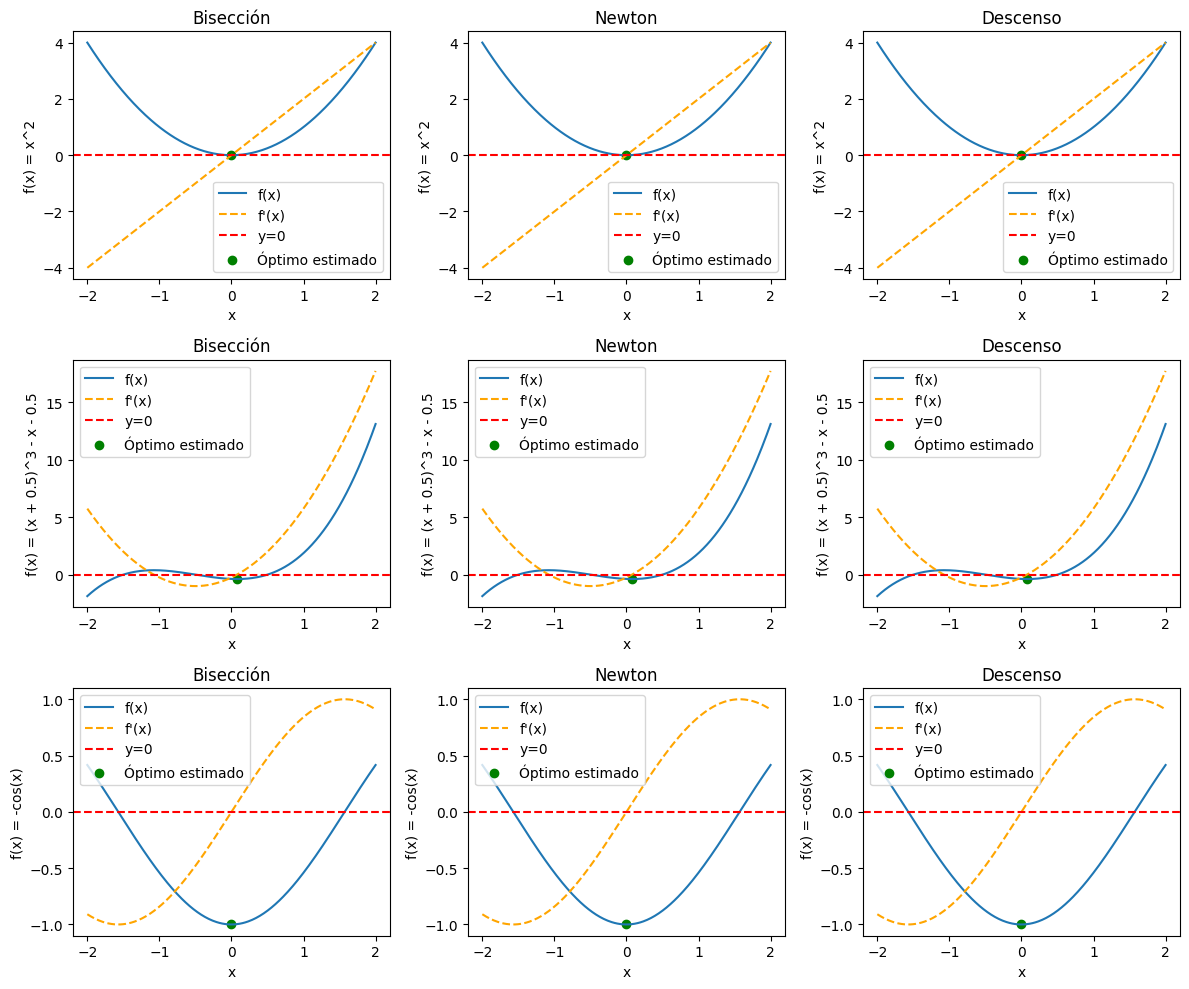

In [26]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.savefig("graficas/seccion2_verificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Aplicación a función no trivial

In [27]:
f = x**2 + 2*sin(3*x)

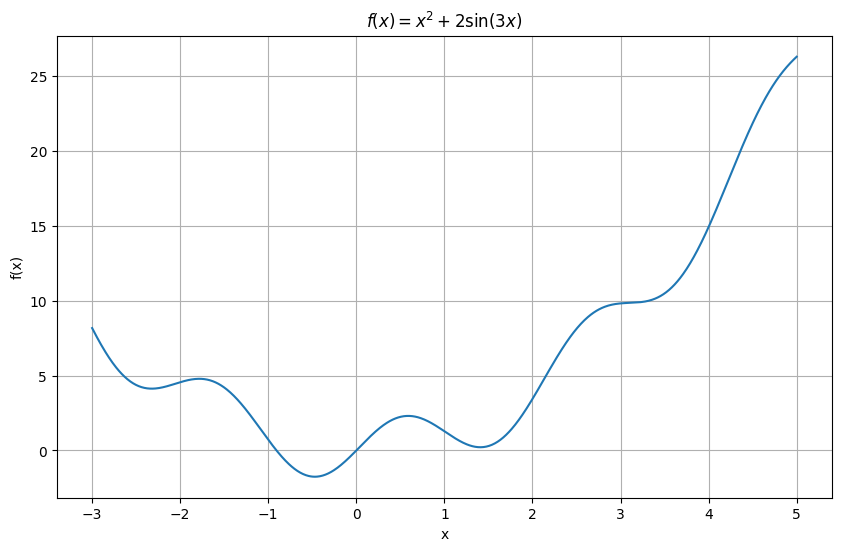

In [28]:
# Grafica de la función
lp = np.linspace(-3, 5, 1000)
plt.figure(figsize=(10,6))
plt.plot(lp, [f.eval(v) for v in lp])
plt.grid(True)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(r"$f(x)=x^2+2\sin(3x)$")
plt.savefig("graficas/seccion3_funcNoTrivial.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# Evaluación de métodos y generación de tablas
results = []
# BISECCIÓN
for a, b in [(-2,1), (-1,0), (1,2)]:
    try:
        root, it = biseccion(f, a, b)
        results.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Resultado": root,
            "f(x)": f.eval(root),
            "Iteraciones": it
        })
    except Exception as e:
        results.append({
            "Método": "Bisección",
            "Inicial": f"[{a},{b}]",
            "Resultado": str(e),
            "f(x)": None,
            "Iteraciones": None
        })

# NEWTON
for x0 in [-2, -1, 4]:
    try:
        root, it = newton(f, x0)
        results.append({
            "Método": "Newton",
            "Inicial": x0,
            "Resultado": root,
            "f(x)": f.eval(root),
            "Iteraciones": it
        })
    except Exception as e:
        results.append({
            "Método": "Newton",
            "Inicial": x0,
            "Resultado": str(e),
            "f(x)": None,
            "Iteraciones": None
        })

# DESCENSO POR GRADIENTE
for x0 in [-3, 0.585, 4]:
    root, it = descenso_gradiente(f, x0, lr=0.05)
    results.append({
        "Método": "Gradiente",
        "Inicial": x0,
        "Resultado": root,
        "f(x)": f.eval(root),
        "Iteraciones": it
    })

tabla = pd.DataFrame(results)
tabla.to_csv("tablas/evaluacion_metodos.csv", index=False)
tabla.to_latex("tablas/evaluacion_metodos.tex", index=False, float_format="%.6f")
tabla

,Método,Inicial,Resultado,f(x),Iteraciones
0,Bisección,"[-2,1]",-1.782932,4.787319,22
1,Bisección,"[-1,0]",-0.471044,-1.753311,20
2,Bisección,"[1,2]",1.407956,0.216284,20
3,Newton,-2,-1.782932,4.787319,6
4,Newton,-1,0.589531,2.308551,5
5,Newton,4,7.820892,59.176196,1000
6,Gradiente,-3,-2.322807,4.129721,15
7,Gradiente,0.585,-0.471043,-1.753311,15
8,Gradiente,4,1.407957,0.216284,32


In [30]:
#Comparación de los learning rates para el método de descenso por gradiente
resultados_gradiente = []
learning_rates = [0.01, 0.05, 0.1]

for lr in learning_rates:
    print(f"\nLearning rate = {lr}")
    for x0 in [-3, 0.585, 4]:
        root, it = descenso_gradiente(
            f,
            x0,
            lr=lr
        )
        resultados_gradiente.append({
            "learning_rate": lr,
            "x0": x0,
            "x_final": root,
            "f(x_final)": f.eval(root),
            "iteraciones": it
        })

df = pd.DataFrame(resultados_gradiente)  
df.to_csv(
    "tablas/learning_rates_gradiente.csv",
    index=False
)

df.to_latex(
    "tablas/learning_rates_gradiente.tex",
    index=False,
    float_format="%.6f"
)

df


Learning rate = 0.01

Learning rate = 0.05

Learning rate = 0.1


,learning_rate,x0,x_final,f(x_final),iteraciones
0,0.01,-3.000,-2.322807,4.129721,109
1,0.01,0.585,-0.471043,-1.753311,110
2,0.01,4.000,1.407957,0.216284,203
3,0.05,-3.000,-2.322807,4.129721,15
4,0.05,0.585,-0.471043,-1.753311,15
5,0.05,4.000,1.407957,0.216284,32
6,0.10,-3.000,-2.322807,4.129721,18
7,0.10,0.585,-0.471043,-1.753311,613
8,0.10,4.000,1.407957,0.216284,64


## Bonus Sección 3
Para esta parte decidimos re-hacer las funciones usadas en la sección anterior, ya que ahora necesitamos más parámetros. Nos pareció más ordenado de esta manera.

In [31]:
def biseccion_historial(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    historial = []
    
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2
        historial.append(mid)
        df_mid = df.eval(mid)
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step, historial
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    return (a + b) / 2, max_iter, historial

def newton_historial(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    d2f = df.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        df_val = df.eval(xn)
        if abs(df_val) < tol:
            return xn, step, historial
        d2f_val = d2f.eval(xn)
        if abs(d2f_val) < 1e-12:
            raise ValueError(f"f''({xn}) ≈ 0: Newton no puede continuar.")
        xn = xn - df_val / d2f_val
        historial.append(xn)

    return xn, max_iter, historial

def descenso_gradiente_historial(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    historial = [xn]

    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        if abs(grad) < tol:
            return xn, step, historial
        xn = xn - lr * grad
        historial.append(xn)

    return xn, max_iter, historial



### Visualización de la trayectoria

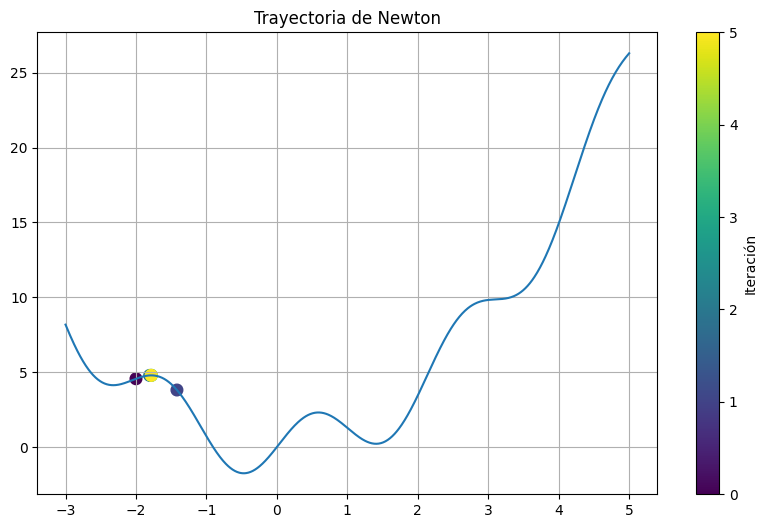

In [32]:
# Con Newton
raiz, it, historial = newton_historial(f, -2)

xs = np.linspace(-3, 5, 1000)
ys = [f.eval(x) for x in xs]

plt.figure(figsize=(10, 6))
plt.plot(xs, ys, label="f(x)")

colores = np.arange(len(historial))

plt.scatter(
    historial,
    [f.eval(x) for x in historial],
    c=colores,
    cmap="viridis",
    s=70
)

plt.colorbar(label="Iteración")

plt.title("Trayectoria de Newton")
plt.grid(True)
plt.savefig("graficas/seccion3_BONUSNewton.png", dpi=150, bbox_inches="tight")

plt.show()

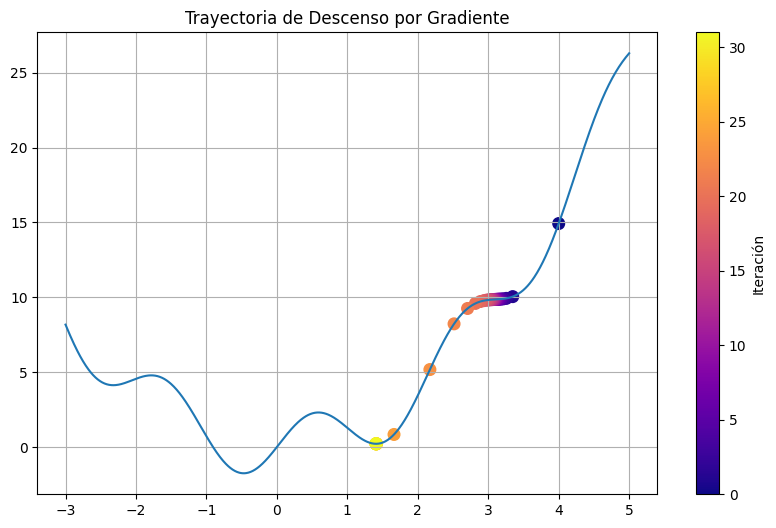

In [33]:
# Con descenso por gradiente
raiz, it, historial = descenso_gradiente_historial(f, x0=4, lr=0.05)

xs = np.linspace(-3, 5, 1000)
ys = [f.eval(x) for x in xs]

plt.figure(figsize=(10, 6))
plt.plot(xs, ys)

plt.scatter(
    historial,
    [f.eval(x) for x in historial],
    c=np.arange(len(historial)),
    cmap="plasma",
    s=70
)

plt.colorbar(label="Iteración")

plt.title("Trayectoria de Descenso por Gradiente")
plt.grid(True)
plt.savefig("graficas/seccion3_BONUSDescensoGradiente.png", dpi=150, bbox_inches="tight")

plt.show()

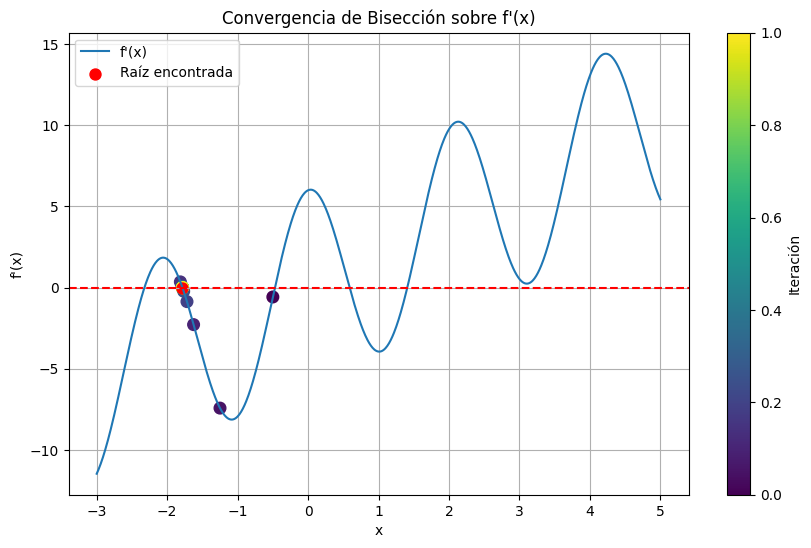

In [34]:
# Con bisección
df = f.derivative()
raiz, it, historial = biseccion_historial(f, -2, 1)
xs = np.linspace(-3, 5, 1000)

plt.figure(figsize=(10,6))

plt.plot(xs, [df.eval(x) for x in xs], label="f'(x)")

plt.axhline(0, color="red", linestyle="--")
plt.scatter(historial, [df.eval(x) for x in historial], c=np.arange(len(historial)), cmap="viridis", s=70)

plt.scatter(raiz, 0, marker=".", s=250, label="Raíz encontrada", color="red")

plt.colorbar(label="Iteración")

plt.title("Convergencia de Bisección sobre f'(x)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid(True)
plt.legend()
plt.savefig("graficas/seccion3_BONUSBiseccion.png", dpi=150, bbox_inches="tight")

plt.show()

# Ajuste de datos

In [35]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [36]:
# Genere la función de pérdida
def funcion_perdida(x_data, y_data, modelo):
    N = len(x_data)

    L = 0
    for xi, yi in zip(x_data, y_data):
        y_hat = modelo(xi)
        L = L + (y_hat - yi)**2

    return L / N

In [37]:
# Optimice la función de pérdida

def descenso_gradiente(f, x0, lr, tol=0.000001, max_iter=1000):
    x = x0
    df = f.derivative()

    for i in range(max_iter):
        grad = df.eval(x)

        if abs(grad) < tol:
            return x, i

        x = x - lr * grad

    return x, max_iter

modelos = {
    "Lineal": {
        "data": df_linear,
        "modelo": lambda xi: w * xi,
        "x0": 0,
        "lr": 0.01,
        "rango_w": np.linspace(-1, 5, 300)
    },
    "Exponencial": {
        "data": df_exp,
        "modelo": lambda xi: exp(w * xi),
        "x0": 0,
        "lr": 0.001,
        "rango_w": np.linspace(-0.5, 0.8, 300)
    },
    "Senoidal": {
        "data": df_sin,
        "modelo": lambda xi: sin(w * xi),
        "x0": 1,
        "lr": 0.01,
        "rango_w": np.linspace(-3, 3, 500)
    }
}

resultados = {}

for nombre, info in modelos.items():
    x_data = info["data"]["x"].values
    y_data = info["data"]["y"].values

    L = funcion_perdida(x_data, y_data, info["modelo"])

    w_optimo, pasos = descenso_gradiente(
        L,
        x0=info["x0"],
        lr=info["lr"],
        max_iter=3000
    )

    resultados[nombre] = {
        "L": L,
        "w_optimo": w_optimo,
        "pasos": pasos,
        "x_data": x_data,
        "y_data": y_data,
        "modelo": info["modelo"],
        "rango_w": info["rango_w"]
    }

    print(nombre)
    print("w óptimo:", w_optimo)
    print("pasos:", pasos)
    print()

Lineal
w óptimo: 1.8479936212016526
pasos: 17

Exponencial
w óptimo: 0.21257607800858003
pasos: 16

Senoidal
w óptimo: 0.6897658763934092
pasos: 61



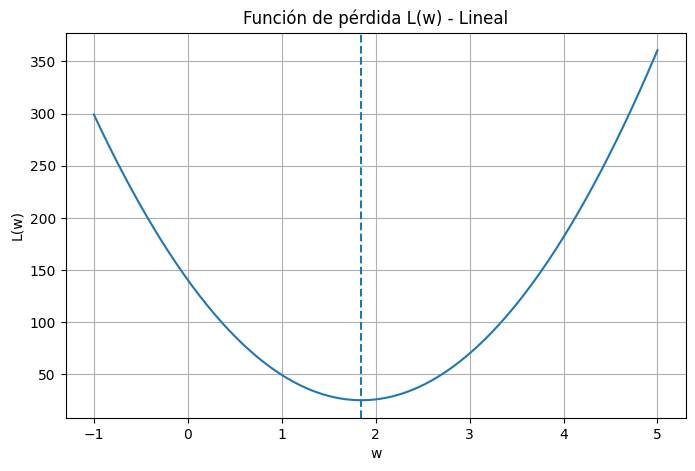

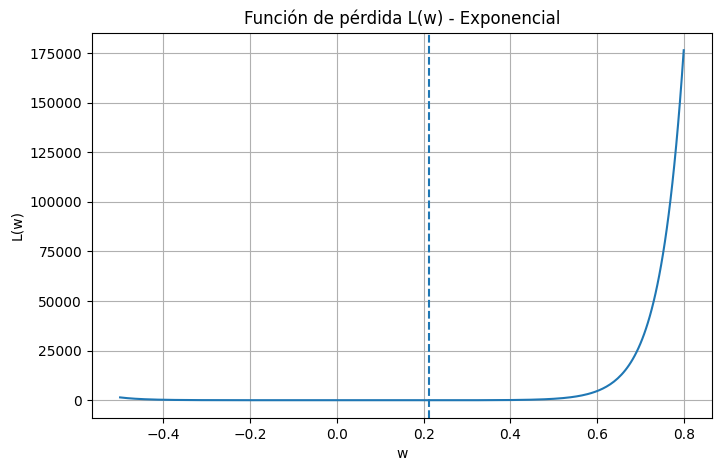

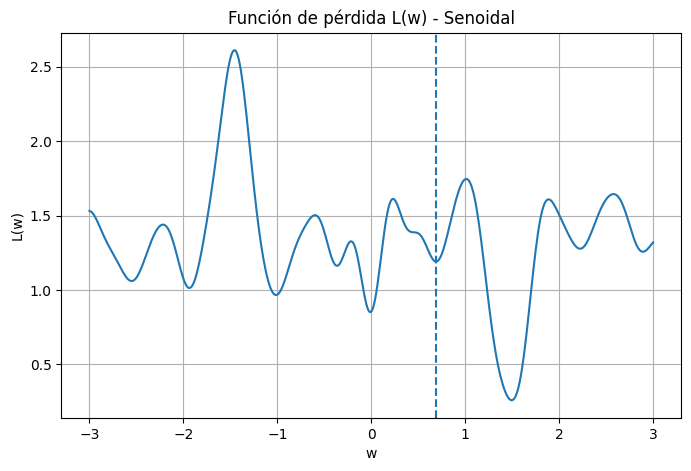

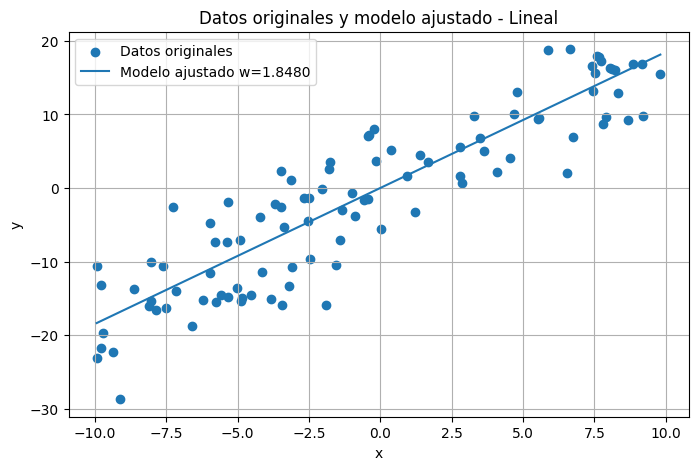

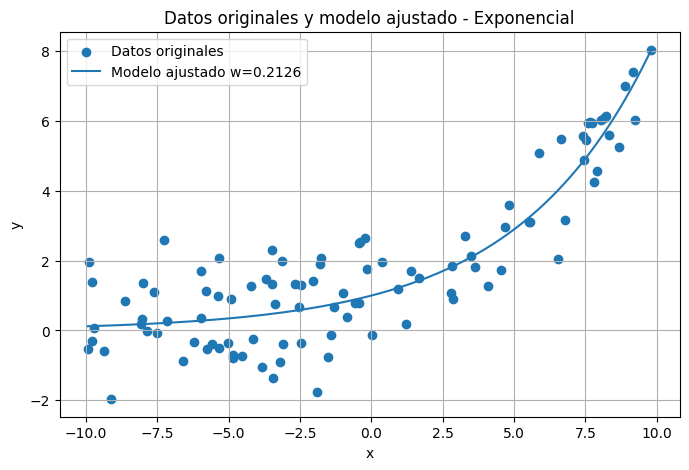

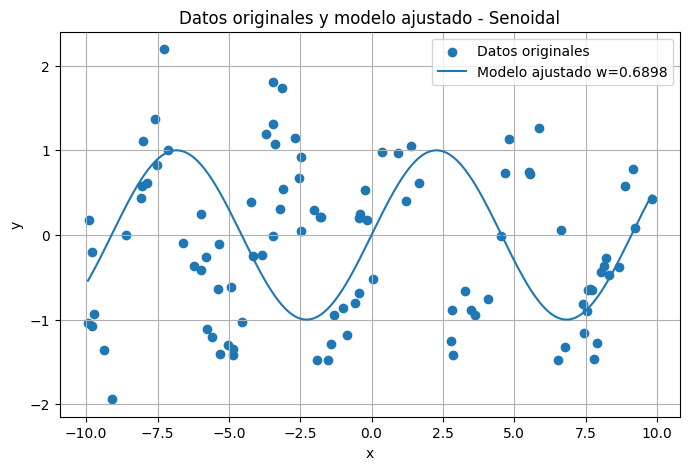

In [38]:
# Grafique datos y ajuste
for nombre, res in resultados.items():
    W = res["rango_w"]
    L = res["L"]

    plt.figure(figsize=(8, 5))
    plt.plot(W, [L.eval(valor) for valor in W])
    plt.axvline(res["w_optimo"], linestyle="--")
    plt.title(f"Función de pérdida L(w) - {nombre}")
    plt.xlabel("w")
    plt.ylabel("L(w)")
    plt.grid(True)
    plt.show()

for nombre, res in resultados.items():
    x_data = res["x_data"]
    y_data = res["y_data"]
    w_optimo = res["w_optimo"]

    x_plot = np.linspace(min(x_data), max(x_data), 300)

    y_plot = []
    for xi in x_plot:
        y_plot.append(res["modelo"](xi).eval(w_optimo))

    plt.figure(figsize=(8, 5))
    plt.scatter(x_data, y_data, label="Datos originales")
    plt.plot(x_plot, y_plot, label=f"Modelo ajustado w={w_optimo:.4f}")
    plt.title(f"Datos originales y modelo ajustado - {nombre}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()    

# BONUS:

=== Modelo Lineal ===
GD estándar - w óptimo: 1.847994 (17 iteraciones), Pérdida final: 25.242044
SGD (Estoc.)- w óptimo: 1.731352 (2000 iteraciones), Pérdida final: 25.701494



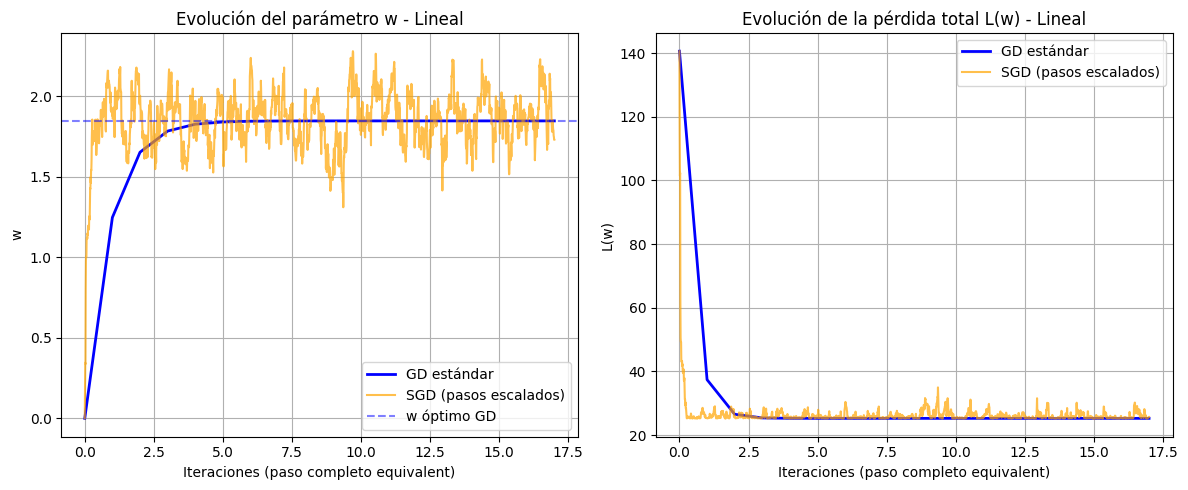

=== Modelo Exponencial ===
GD estándar - w óptimo: 0.212576 (16 iteraciones), Pérdida final: 0.994378
SGD (Estoc.)- w óptimo: 0.209960 (2000 iteraciones), Pérdida final: 0.997467



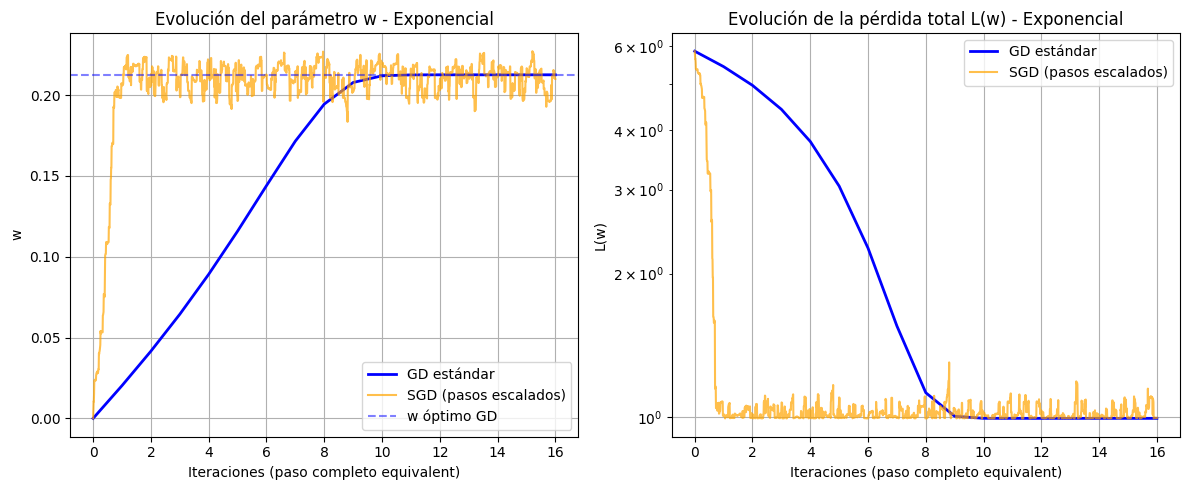

=== Modelo Senoidal ===
GD estándar - w óptimo: 0.689766 (61 iteraciones), Pérdida final: 1.191344
SGD (Estoc.)- w óptimo: 0.656410 (5000 iteraciones), Pérdida final: 1.205603



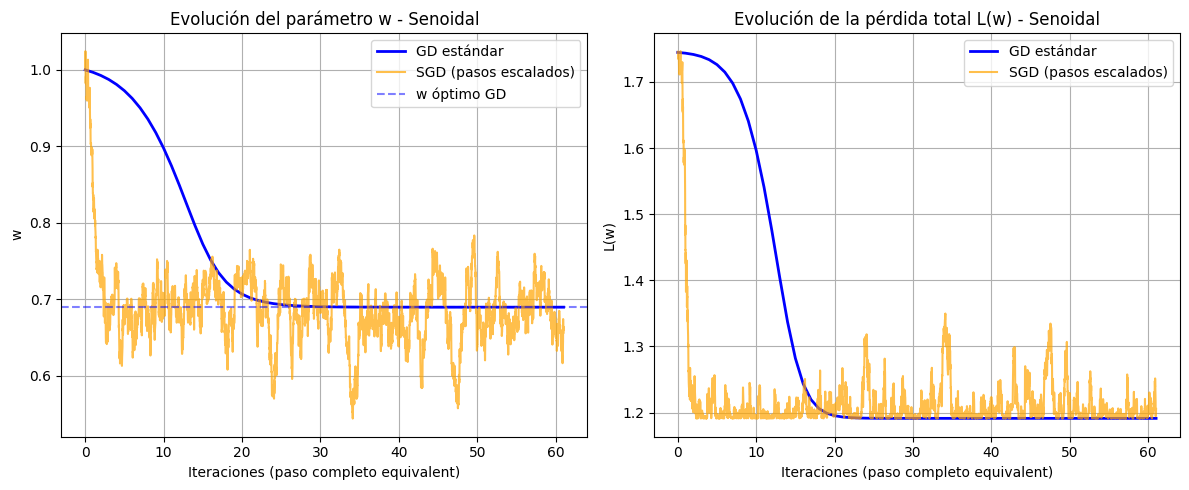

In [40]:
# Implementación de SGD que selecciona un índice aleatorio en cada iteración y actualiza utilizando l'_i(w)
def descenso_gradiente_estocastico_con_historial(x_data, y_data, modelo, x0: float, lr: float, max_iter: int = 3000):
    np.random.seed(42)  # Para reproducibilidad en la selección aleatoria de datos
    x = x0
    N = len(x_data)
    
    # Precalcular las funciones de pérdida individuales y sus derivadas simbólicas
    dl_terms = []
    for xi, yi in zip(x_data, y_data):
        l_i = (modelo(xi) - yi)**2
        dl_terms.append(l_i.derivative())
        
    history = [x]
    for i in range(max_iter):
        # En cada iteración, seleccionar un índice i al azar
        idx = np.random.randint(0, N)
        # Actualizar w utilizando el gradiente del término i
        grad = dl_terms[idx].eval(x)
        x = x - lr * grad
        history.append(x)
        
    return x, history

# Configuración de experimentos para los tres problemas de ajuste de datos
modelos_sgd = {
    "Lineal": {
        "data": df_linear,
        "modelo": lambda xi: w * xi,
        "x0": 0.0,
        "lr_gd": 0.01,
        "lr_sgd": 0.001,       # Se usa una tasa menor para estabilizar las oscilaciones de SGD
        "max_iter_gd": 200,
        "max_iter_sgd": 2000
    },
    "Exponencial": {
        "data": df_exp,
        "modelo": lambda xi: exp(w * xi),
        "x0": 0.0,
        "lr_gd": 0.001,
        "lr_sgd": 0.0001,
        "max_iter_gd": 200,
        "max_iter_sgd": 2000
    },
    "Senoidal": {
        "data": df_sin,
        "modelo": lambda xi: sin(w * xi),
        "x0": 1.0,
        "lr_gd": 0.01,
        "lr_sgd": 0.001,
        "max_iter_gd": 500,
        "max_iter_sgd": 5000
    }
}

import os
os.makedirs("graficas", exist_ok=True)

for nombre, info in modelos_sgd.items():
    x_data = info["data"]["x"].values
    y_data = info["data"]["y"].values
    modelo_func = info["modelo"]
    x0 = info["x0"]
    
    # 1. Pérdida completa L(w) para evaluación e historial de pérdidas
    N = len(x_data)
    L = 0
    for xi, yi in zip(x_data, y_data):
        L = L + (modelo_func(xi) - yi)**2
    L = L / N
    
    # 2. Ejecutar Descenso por Gradiente Estándar (GD)
    w_gd, it_gd, hist_gd = descenso_gradiente_historial(L,x0,info["lr_gd"],max_iter=info["max_iter_gd"])
    
    # 3. Ejecutar Descenso por Gradiente Estocástico (SGD)
    w_sgd, hist_sgd = descenso_gradiente_estocastico_con_historial(x_data, y_data, modelo_func, x0, info["lr_sgd"], max_iter=info["max_iter_sgd"])

    # Evaluar pérdidas para los historiales de optimización
    loss_gd = [L.eval(val) for val in hist_gd]
    loss_sgd = [L.eval(val) for val in hist_sgd]
    
    print(f"=== Modelo {nombre} ===")
    print(f"GD estándar - w óptimo: {w_gd:.6f} ({len(hist_gd)-1} iteraciones), Pérdida final: {loss_gd[-1]:.6f}")
    print(f"SGD (Estoc.)- w óptimo: {w_sgd:.6f} ({len(hist_sgd)-1} iteraciones), Pérdida final: {loss_sgd[-1]:.6f}")
    print()
    
    # 4. Graficar y comparar comportamientos
    plt.figure(figsize=(12, 5))
    
    # Gráfico del parámetro w
    plt.subplot(1, 2, 1)
    plt.plot(hist_gd, label="GD estándar", color="blue", linewidth=2)
    plt.plot(np.linspace(0, len(hist_gd)-1, len(hist_sgd)), hist_sgd, label="SGD (pasos escalados)", color="orange", alpha=0.7)
    plt.axhline(w_gd, color="blue", linestyle="--", alpha=0.5, label="w óptimo GD")
    plt.title(f"Evolución del parámetro w - {nombre}")
    plt.xlabel("Iteraciones (paso completo equivalent)")
    plt.ylabel("w")
    plt.legend()
    plt.grid(True)
    
    # Gráfico de la pérdida total L(w)
    plt.subplot(1, 2, 2)
    plt.plot(loss_gd, label="GD estándar", color="blue", linewidth=2)
    plt.plot(np.linspace(0, len(loss_gd)-1, len(loss_sgd)), loss_sgd, label="SGD (pasos escalados)", color="orange", alpha=0.7)
    plt.title(f"Evolución de la pérdida total L(w) - {nombre}")
    plt.xlabel("Iteraciones (paso completo equivalent)")
    plt.ylabel("L(w)")
    if nombre == "Exponencial":
        plt.yscale("log")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f"graficas/bonus_sgd_{nombre.lower()}.png", dpi=150, bbox_inches="tight")
    plt.show()


=== Optimización de f(x) = x^2 + 2*sin(3*x) ===
GD Constante (lr=0.15) - x final: 0.923549, f(x) final: 1.577935
GD Variable (lr0=0.15) - x final: 1.407957, f(x) final: 0.216284



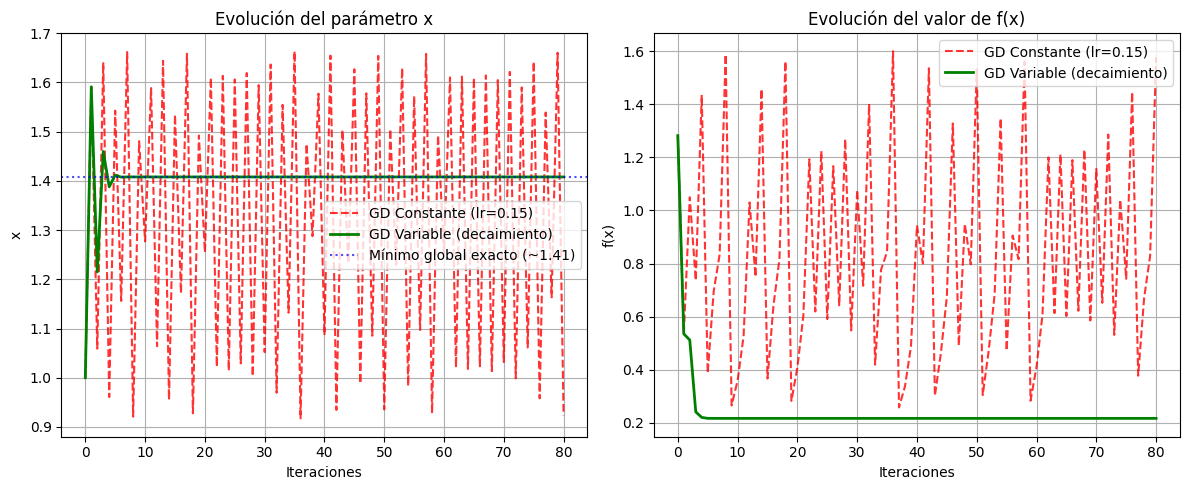

In [41]:
# Implementación de GD con learning rate variable (decaimiento por raíz cuadrada)
def descenso_gradiente_variable(f: Function, x0: float, lr0: float, max_iter: int = 100):
    x_val = x0
    df = f.derivative()
    history = [x_val]
    for k in range(max_iter):
        # Programación de tasa de aprendizaje: decaimiento por raíz cuadrada
        lr = lr0 / np.sqrt(k + 1)
        grad = df.eval(x_val)
        x_val = x_val - lr * grad
        history.append(x_val)
    return x_val, history

# Parámetros del experimento
x0_val = 1.0
lr0_val = 0.15      # Una tasa de aprendizaje constante de 0.15 causa oscilaciones estables e impide la convergencia
iteraciones = 80

# 1. Ejecutar GD clásico con tasa constante (reutilizando la función con historial)
x_const, it_const, hist_const = descenso_gradiente_historial(f,x0_val,lr0_val,max_iter=iteraciones,tol=1e-12)


# 2. Ejecutar GD con tasa variable
x_var, hist_var = descenso_gradiente_variable(f, x0_val, lr0_val, max_iter=iteraciones)

# Evaluar el valor de la función de pérdida f(x) a lo largo de las iteraciones
loss_const = [f.eval(val) for val in hist_const]
loss_var = [f.eval(val) for val in hist_var]

print("=== Optimización de f(x) = x^2 + 2*sin(3*x) ===")
print(f"GD Constante (lr={lr0_val}) - x final: {x_const:.6f}, f(x) final: {loss_const[-1]:.6f}")
print(f"GD Variable (lr0={lr0_val}) - x final: {x_var:.6f}, f(x) final: {loss_var[-1]:.6f}")
print()

# 3. Graficar comparación de trayectorias
plt.figure(figsize=(12, 5))

# Evolución del parámetro x
plt.subplot(1, 2, 1)
plt.plot(hist_const, label=f"GD Constante (lr={lr0_val})", color="red", linestyle="--", alpha=0.8)
plt.plot(hist_var, label="GD Variable (decaimiento)", color="green", linewidth=2)
plt.axhline(1.407957, color="blue", linestyle=":", alpha=0.7, label="Mínimo global exacto (~1.41)")
plt.title("Evolución del parámetro x")
plt.xlabel("Iteraciones")
plt.ylabel("x")
plt.legend()
plt.grid(True)

# Evolución de f(x)
plt.subplot(1, 2, 2)
plt.plot(loss_const, label=f"GD Constante (lr={lr0_val})", color="red", linestyle="--", alpha=0.8)
plt.plot(loss_var, label="GD Variable (decaimiento)", color="green", linewidth=2)
plt.title("Evolución del valor de f(x)")
plt.xlabel("Iteraciones")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("graficas/bonus_lr_variable.png", dpi=150, bbox_inches="tight")
plt.show()


In [42]:
# 1. Definición de la pérdida en la formulación de producto de exponenciales para el dataset lineal
# w_gd es el óptimo que encontramos anteriormente en la sección de ajuste de datos para el modelo Lineal (~1.848)
# Cargamos los datos del dataset lineal
x_data = df_linear["x"].values
y_data = df_linear["y"].values
w_gd = resultados["Lineal"]["w_optimo"]

# Construimos la productoria simbólica de las exponenciales: L_tilde = \prod e^{-(wx_i - y_i)^2}
L_tilde = 1
for xi, yi in zip(x_data, y_data):
    L_tilde = L_tilde * exp(-(w * xi - yi)**2)

# Minimizar -L_tilde equivale a maximizar L_tilde
loss_product = -L_tilde

# 2. Evaluaciones del valor de la pérdida y de su gradiente en el dataset completo (N=100)
loss_val_0 = loss_product.eval(0.0)
grad_val_0 = loss_product.derivative().eval(0.0)
loss_val_opt = loss_product.eval(w_gd)
grad_val_opt = loss_product.derivative().eval(w_gd)

print("=== Evaluación con Dataset Completo (N=100) ===")
print(f"Pérdida -L_tilde(0): {loss_val_0}")
print(f"Gradiente -L_tilde'(0): {grad_val_0}")
print(f"Pérdida -L_tilde(w_optimo): {loss_val_opt}")
print(f"Gradiente -L_tilde'(w_optimo): {grad_val_opt}")
print()

# Intentamos optimizar con descenso por gradiente estándar sobre loss_product
print("=== Ejecución de GD sobre la Formulación Producto (N=100) ===")
w_prod_final, it_prod, hist_prod = descenso_gradiente_historial(loss_product, x0=0.0, lr=0.01, max_iter=10)
print(f"w final obtenido: {w_prod_final}")
print(f"Trayectoria de w: {hist_prod}")
print()

# 3. Experimento complementario con un dataset reducido (N=3) para ilustrar la escala de magnitud
x_data_3 = x_data[:3]
y_data_3 = y_data[:3]

L_tilde_3 = 1
for xi, yi in zip(x_data_3, y_data_3):
    L_tilde_3 = L_tilde_3 * exp(-(w * xi - yi)**2)
loss_product_3 = -L_tilde_3

loss_val_3_0 = loss_product_3.eval(0.0)
grad_val_3_0 = loss_product_3.derivative().eval(0.0)

print("=== Evaluación con Dataset Reducido (N=3) ===")
print(f"Pérdida -L_tilde_3(0): {loss_val_3_0}")
print(f"Gradiente -L_tilde_3'(0): {grad_val_3_0}")

# Intentamos correr pasos con tasa estándar (lr = 0.01) y tasa gigante (lr = 1e160)
_, it_prod_3_std, hist_prod_3_std = descenso_gradiente_historial(loss_product_3, x0=0.0, lr=0.01, max_iter=5)
print(f"GD (lr=0.01) - Historial de w: {hist_prod_3_std}")

_, it_prod_3_big, hist_prod_3_big = descenso_gradiente_historial(loss_product_3, x0=0.0, lr=1e160, max_iter=5)
print(f"GD (lr=1e160) - Historial de w: {hist_prod_3_big}")


=== Evaluación con Dataset Completo (N=100) ===
Pérdida -L_tilde(0): -0.0
Gradiente -L_tilde'(0): -0.0
Pérdida -L_tilde(w_optimo): -0.0
Gradiente -L_tilde'(w_optimo): -0.0

=== Ejecución de GD sobre la Formulación Producto (N=100) ===
w final obtenido: 0.0
Trayectoria de w: [0.0]

=== Evaluación con Dataset Reducido (N=3) ===
Pérdida -L_tilde_3(0): -5.760802730034922e-163
Gradiente -L_tilde_3'(0): -4.642626789233178e-161
GD (lr=0.01) - Historial de w: [0.0]
GD (lr=1e160) - Historial de w: [0.0]
